# Detecting inherent linearity in large CNNs

This Notebook serves to experiment with detecting inherent linearity in ResNets. These experiments will be run on smaller instances of ResNets to test functionality and provide evidence for a feasibility study as part of the graduation preparation phase. Larger experiments for the final paper(s) will be handled using Python files in this repository.

In [2]:
import torch
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torch.utils.data import Subset
import numpy as np
from tqdm import tqdm

# --- CUDA sanity ---
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(torch.version.cuda)

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

print(torch.backends.cuda.matmul.allow_tf32)
print(torch.backends.cudnn.allow_tf32)

True
NVIDIA GeForce RTX 4080 SUPER
13.0
True
True


In [3]:
def make_subset(dataset, fraction=0.1, seed=42):
    np.random.seed(seed)
    indices = np.random.choice(
        len(dataset),
        int(len(dataset) * fraction),
        replace=False
    )
    return Subset(dataset, indices)


train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

val_tfms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

train_ds = ImageFolder("./data/imagenet_train", transform=train_tfms)
train_ds = make_subset(train_ds, fraction=0.05)
val_ds = ImageFolder("./data/imagenet_val", transform=val_tfms)

train_loader = DataLoader(
    train_ds, batch_size=256, shuffle=True,
    num_workers=0, pin_memory=True
)

val_loader = DataLoader(
    val_ds, batch_size=128, shuffle=False,
    num_workers=0, pin_memory=True
)

model = resnet18(weights=ResNet18_Weights.DEFAULT).cuda().eval()

### Verifying the model and data loader work correctly

In [4]:
def verify_model_and_data_loader(model, data_loader, device="cuda", num_batches=1):
    """
    Verify that the model and data loader work correctly by performing a forward
    pass on ImageNet-sized inputs.

    Args:
        model: ImageNet-native neural network (e.g. ResNet-18)
        data_loader: DataLoader over ImageNet val (ImageFolder)
        device: Device to run computations on
        num_batches: Number of batches to run

    Returns:
        torch.Tensor: Concatenated outputs from the first num_batches
    """

    # --- move model once ---
    model = model.to(device).eval()

    outputs = []

    with torch.no_grad():
        for inputs, _ in tqdm(data_loader, desc="Doing ImageNet forward passes", leave=False):
            # ImageNet inputs: N×3×224×224
            inputs = inputs.to(device)

            output = model(inputs)
            outputs.append(output)

            if len(outputs) >= num_batches:
                break

    return torch.cat(outputs, dim=0)

outputs = verify_model_and_data_loader(model, val_loader)
print(outputs.shape)

torch.Size([128, 1000])


## Computing the mean of preactivations per ReLU layer
"**Mean of preactivations $\bar{p}^l$** We denote the distribution of inputs $z$ to a nonlinear activation function $f(z)$ as the preactivations. For each activation function/node, we compute the mean of the preactivations, and then we compute another mean of these values per layer $l$: $\bar{p}^l= \frac{1}{M}\sum_{i=1}^M \left(\frac{1}{N}\sum_{s=1}^N z_{s,i}^l\right)$,
with $M$ the number of nodes in layer $l$ and $N$ the number of samples, and $z_{s,i}^l$ the preactivation value for sample $s$ at node $i$ at layer $l$. We compute this value through randomly selecting 500 samples of the input data instead of the whole dataset, which significantly reduces the computational cost." (Pinson et al., 2024, p. 3).

In case there is BatchNormalization applied between the convolution and the activation function, the mean of the preactivations will be approximately 0, due to the normalization. However, BN has two learned parameters per channel, namely a scaling and a shifting parameter. The shifting parameter can be used to recover the mean of the preactivations before BN. Therefore, in case of BN, we will use the shifting parameter as the mean of the preactivations. (Pinson et al., 2024)

In [5]:
def retrieve_mean_preactivations(model, data_loader, device='cuda'):
    """Compute the mean of preactivations for each ReLU layer in the model. Function does this by reading the learned shift parameter of the preceding BatchNormalization layer, as the shift will cause an inaccurate mean when computed at the ReLU layer. Returns a dictionary with layer names as keys and mean preactivation values as values.
    Args:
        model: The neural network model.
        data_loader: DataLoader for the input data.
        device: Device to run the computations on.

    Returns:
        dict: A dictionary with layer names as keys and mean preactivation values as values.
    """
    model.to(device)
    model.eval()

    batchnorms = {}
    mean_preactivations = {}
    hooks = []

    def get_hook(name):
        def hook(module, input, output):
            # If the layer is a proper BatchNorm and it isn't the last in the block, save it with its shift parameter
            if isinstance(module, torch.nn.BatchNorm2d) and 'downsample' not in name and name.split('bn')[-1] < '2':
                shift = module.bias.mean().item()
                layer = name.split('bn')[0]  # Get the layer name before .bn
                batchnorms[layer] = shift
            # If the layer is ReLU, check if there was a preceding BatchNorm
            elif isinstance(module, torch.nn.ReLU):
                layer = name.split('relu')[0]  # Get the layer name before .relu
                if layer in batchnorms:
                    mean_preactivations[name] = batchnorms[layer]
                else:
                    # Compute mean preactivation directly
                    print(f"Computing mean preactivation for layer {name} without preceding BatchNorm.")
                    preactivations = input[0]
                    mean_preactivation = preactivations.mean().item()
                    mean_preactivations[name] = mean_preactivation
        return hook

    for name, module in tqdm(model.named_modules(), desc="Registering hooks", leave=False):
        if isinstance(module, (torch.nn.ReLU, torch.nn.BatchNorm2d)):
            hooks.append(module.register_forward_hook(get_hook(name)))
    with torch.no_grad():
        for inputs, _ in tqdm(data_loader, desc="Computing mean preactivations", leave=False):
            inputs = inputs.to(device)
            model(inputs)
            break  # Only need one batch for mean preactivations
    for hook in tqdm(hooks, desc="Removing hooks", leave=False):
        hook.remove()
    return mean_preactivations


mean_preacts = retrieve_mean_preactivations(model, val_loader)
print(mean_preacts)

{'relu': 0.18112018704414368, 'layer1.0.relu': -0.0341365709900856, 'layer1.1.relu': -0.08357393741607666, 'layer2.0.relu': -0.06734631955623627, 'layer2.1.relu': -0.2102503776550293, 'layer3.0.relu': -0.11478555202484131, 'layer3.1.relu': -0.23746797442436218, 'layer4.0.relu': -0.22572244703769684, 'layer4.1.relu': -0.24174048006534576}


The mean of preactivations can indicate whether the preceding layer is operating in a linear regime. For ReLU activations, a mean preactivation close to zero indicates that the layer is likely operating in a more linear regime, as many inputs will be negative and thus output zero. Conversely, a mean preactivation significantly greater than zero suggests that the layer is operating in a more nonlinear regime, as more inputs will be positive and thus pass through the ReLU unchanged. Below we copy the mean preactivations to the preceding Conv2d layer for easier analysis later on.

In [6]:
mean_preacts_conv = {}
for name, module in model.named_modules():
    if isinstance(module, torch.nn.ReLU):
        mean = mean_preacts.get(name, 0.0)
        layer = name.split('relu')[0]  # Get the layer name before .relu
        mean_preacts_conv[layer + 'conv1'] = mean  # Assign to preceding Conv2d layer

In [7]:
# Print all model layers neatly, and remark the mean preactivations for ReLU and the two learned parameters of BatchNorm2d
for name, module in model.named_modules():
    if isinstance(module, torch.nn.ReLU):
        mean = mean_preacts.get(name, 0.0)
        print(f"Layer: {name} (ReLU), Mean preactivation: {mean:.6f}")
    elif isinstance(module, torch.nn.BatchNorm2d):
        gamma = model.state_dict()[f"{name}.weight"].mean().item()
        beta = model.state_dict()[f"{name}.bias"].mean().item()
        print(f"Layer: {name} (BatchNorm2d), gamma (scale): {gamma:.6f}, beta (shift/mean preactivation): {beta:.6f}")
    elif isinstance(module, torch.nn.Conv2d):
        mean = mean_preacts_conv.get(name, None)
        if mean is not None:
            print(f"Layer: {name} (Conv2d), Mean preactivation (from following ReLU): {mean:.6f}")
    else:
        print(f"Layer: {name} ({module.__class__.__name__})")
# This can be used to verify that the mean preactivations for the ReLU layers were properly copied from preceding BatchNorm layers.

Layer:  (ResNet)
Layer: conv1 (Conv2d), Mean preactivation (from following ReLU): 0.181120
Layer: bn1 (BatchNorm2d), gamma (scale): 0.257577, beta (shift/mean preactivation): 0.181120
Layer: relu (ReLU), Mean preactivation: 0.181120
Layer: maxpool (MaxPool2d)
Layer: layer1 (Sequential)
Layer: layer1.0 (BasicBlock)
Layer: layer1.0.conv1 (Conv2d), Mean preactivation (from following ReLU): -0.034137
Layer: layer1.0.bn1 (BatchNorm2d), gamma (scale): 0.339601, beta (shift/mean preactivation): -0.034137
Layer: layer1.0.relu (ReLU), Mean preactivation: -0.034137
Layer: layer1.0.bn2 (BatchNorm2d), gamma (scale): 0.333055, beta (shift/mean preactivation): 0.003463
Layer: layer1.1 (BasicBlock)
Layer: layer1.1.conv1 (Conv2d), Mean preactivation (from following ReLU): -0.083574
Layer: layer1.1.bn1 (BatchNorm2d), gamma (scale): 0.328692, beta (shift/mean preactivation): -0.083574
Layer: layer1.1.relu (ReLU), Mean preactivation: -0.083574
Layer: layer1.1.bn2 (BatchNorm2d), gamma (scale): 0.392430, b

## Pruning the model and identifying the pruned layers
To see whether pruning strategies target the layers that are more linear, we will prune the model using a couple methods. First, we will use a pruning method without layer-specific pruning ratios to see if the pruning method will target linear layers. For quick initial results, the [Torch-Pruning](https://github.com/VainF/Torch-Pruning) library will be used. Later, pruning methods will be chosen from literature such that there is a clear scientific basis for the pruning method.

In [8]:
import torch_pruning as tp

prune_model = resnet18(weights=ResNet18_Weights.DEFAULT).cuda().eval()

def l1_structured_prune_resnet(
    model,
    data_loader,
    device,
    pruning_ratio=0.3,
    iterative_steps=1,
    example_input_shape=(1, 3, 224, 224),
    ignore_last_fc=True,
):
    """
    L1-norm structured channel pruning for ResNet using Torch-Pruning.

    Returns:
        model (torch.nn.Module): pruned model
        layer_pruning_ratios (dict): {layer_name: pruning_ratio}
    """

    model = model.to(device)
    model.eval()

    # ----------------------------------------------------
    # 0. Record original channel counts
    # ----------------------------------------------------
    original_channels = dict()
    for name, module in model.named_modules():
        if isinstance(module, torch.nn.Conv2d):
            original_channels[name] = module.out_channels
        elif isinstance(module, torch.nn.Linear):
            original_channels[name] = module.out_features

    # ----------------------------------------------------
    # 1. Build example inputs
    # ----------------------------------------------------
    try:
        example_inputs, _ = next(iter(data_loader))
        example_inputs = example_inputs[:1].to(device)
    except Exception:
        example_inputs = torch.randn(example_input_shape).to(device)

    # ----------------------------------------------------
    # 2. Define L1 importance
    # ----------------------------------------------------
    importance = tp.importance.MagnitudeImportance(
        p=1,
        group_reduction="sum"
    )

    # ----------------------------------------------------
    # 3. Select ignored layers
    # ----------------------------------------------------
    ignored_layers = []
    if ignore_last_fc and hasattr(model, "fc"):
        ignored_layers.append(model.fc)

    # ----------------------------------------------------
    # 4. Create pruner
    # ----------------------------------------------------
    pruner = tp.pruner.MagnitudePruner(
        model,
        example_inputs=example_inputs,
        importance=importance,
        pruning_ratio=pruning_ratio,
        iterative_steps=iterative_steps,
        ignored_layers=ignored_layers,
    )

    # ----------------------------------------------------
    # 5. Execute pruning
    # ----------------------------------------------------
    pruner.step()

    # ----------------------------------------------------
    # 6. Compute per-layer pruning ratios
    # ----------------------------------------------------
    layer_pruning_ratios = dict()

    for name, module in model.named_modules():
        if name not in original_channels:
            continue

        if isinstance(module, torch.nn.Conv2d):
            remaining = module.out_channels
        elif isinstance(module, torch.nn.Linear):
            remaining = module.out_features
        else:
            continue

        original = original_channels[name]
        ratio = 1.0 - (remaining / original)
        layer_pruning_ratios[name] = ratio

    return model, layer_pruning_ratios

pruned_model, pruned_layers = l1_structured_prune_resnet(prune_model, val_loader, 'cuda', pruning_ratio=0.3, iterative_steps=1)
print(pruned_layers)

{'conv1': 0.3125, 'layer1.0.conv1': 0.3125, 'layer1.0.conv2': 0.3125, 'layer1.1.conv1': 0.3125, 'layer1.1.conv2': 0.3125, 'layer2.0.conv1': 0.3046875, 'layer2.0.conv2': 0.3046875, 'layer2.0.downsample.0': 0.3046875, 'layer2.1.conv1': 0.3046875, 'layer2.1.conv2': 0.3046875, 'layer3.0.conv1': 0.30078125, 'layer3.0.conv2': 0.30078125, 'layer3.0.downsample.0': 0.30078125, 'layer3.1.conv1': 0.30078125, 'layer3.1.conv2': 0.30078125, 'layer4.0.conv1': 0.30078125, 'layer4.0.conv2': 0.30078125, 'layer4.0.downsample.0': 0.30078125, 'layer4.1.conv1': 0.30078125, 'layer4.1.conv2': 0.30078125, 'fc': 0.0}


## Analyzing the correlation between mean preactivations and pruning ratios
Now that we have both the mean preactivations per ReLU layer and the pruning ratios per layer, we can analyze the correlation between these two metrics. Below we list each layer, and list its pruning ratio and mean preactivation, if applicable.

In [9]:
import pandas as pd

data = []
for name, module in model.named_modules():
    mean_preact = mean_preacts_conv.get(name, None)
    pruning_ratio = pruned_layers.get(name, None)
    if mean_preact is not None and pruning_ratio is not None:
        data.append({
            "Layer": name,
            "Mean Preactivation": mean_preact,
            "Pruning Ratio": pruning_ratio
        })
df = pd.DataFrame(data)

# Display the DataFrame
print(df)

            Layer  Mean Preactivation  Pruning Ratio
0           conv1            0.181120       0.312500
1  layer1.0.conv1           -0.034137       0.312500
2  layer1.1.conv1           -0.083574       0.312500
3  layer2.0.conv1           -0.067346       0.304688
4  layer2.1.conv1           -0.210250       0.304688
5  layer3.0.conv1           -0.114786       0.300781
6  layer3.1.conv1           -0.237468       0.300781
7  layer4.0.conv1           -0.225722       0.300781
8  layer4.1.conv1           -0.241740       0.300781


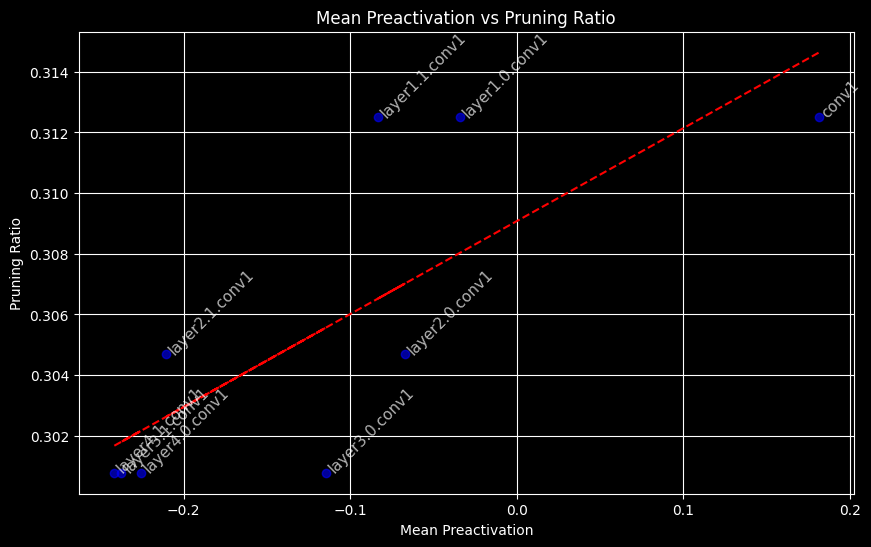

In [10]:
from matplotlib import pyplot as plt

# Scatter plot of Mean Preactivation vs Pruning Ratio, including a trend line
plt.figure(figsize=(10, 6))
plt.scatter(df["Mean Preactivation"], df["Pruning Ratio"], color='blue', alpha=0.6)
plt.title("Mean Preactivation vs Pruning Ratio")
plt.xlabel("Mean Preactivation")
plt.ylabel("Pruning Ratio")

# Label the points with layer names at 45 degree angle
for i, row in df.iterrows():
    plt.text(row["Mean Preactivation"], row["Pruning Ratio"], row["Layer"], fontsize=11, alpha=0.7, rotation=45)

# Fit and plot a trend line
z = np.polyfit(df["Mean Preactivation"], df["Pruning Ratio"], 1)
p = np.poly1d(z)
plt.plot(df["Mean Preactivation"], p(df["Mean Preactivation"]), "r--")
plt.grid()
plt.show()

## Average of three experiments with fixed random seed

Now we will rerun the entire experiment three times with three fixed random seeds to get an average performance indication. The averages will be graphed again to see if the trend is clearer.

Running experiment with seed 42...


Running experiment with seed 66...


Running experiment with seed 762...


Results saved to ./cnn_pruning_linearity_results.csv


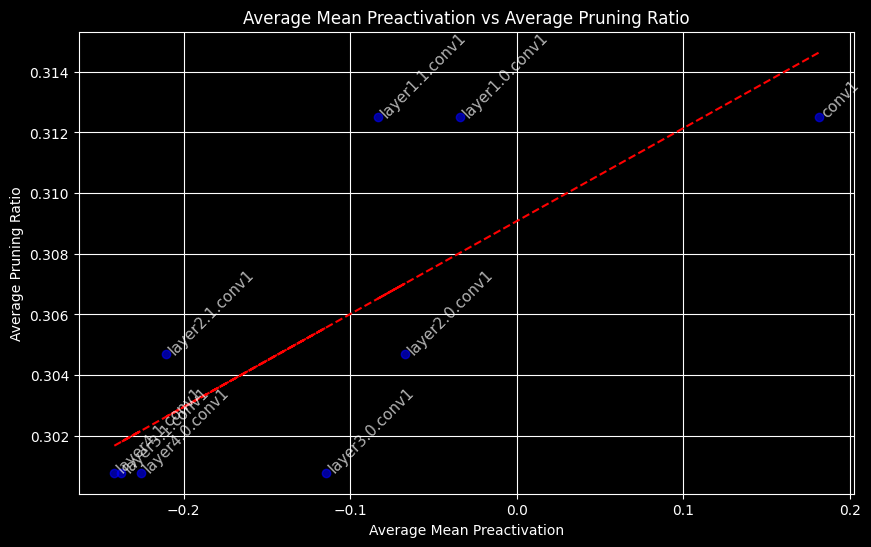

None


In [13]:
def do_fixed_experiments(seeds, verbose=True, graph=True, save_path=None):
    """Run the entire experiment with fixed seeds from a provided list. Function can report mean preactivations, pruning ratios, and their correlation for each seed, and can save the results to a csv file if a save path is provided. Graph will be of averaged results across all seeds.
    seeds (list of int): List of random seeds to use.
    verbose (bool): Whether to print detailed output.
    graph (bool): Whether to plot the correlation graph.
    save_path (str or None): If provided, path to save results to a csv file. Graph will also be saved as a png file in the same location.
    """
    all_data = []
    for seed in seeds:
        if verbose:
            print(f"Running experiment with seed {seed}...")
        torch.manual_seed(seed)
        np.random.seed(seed)

        # Reinitialize model and data loader
        model = resnet18(weights=ResNet18_Weights.DEFAULT).cuda().eval()
        prune_model = resnet18(weights=ResNet18_Weights.DEFAULT).cuda().eval()

        # Retrieve mean preactivations
        mean_preacts = retrieve_mean_preactivations(model, val_loader)
        mean_preacts_conv = {}
        for name, module in model.named_modules():
            if isinstance(module, torch.nn.ReLU):
                mean = mean_preacts.get(name, 0.0)
                layer = name.split('relu')[0]
                mean_preacts_conv[layer + 'conv1'] = mean

        # Prune the model
        pruned_model, pruned_layers = l1_structured_prune_resnet(prune_model, val_loader, 'cuda', pruning_ratio=0.3, iterative_steps=1)

        # Collect data
        for name, module in model.named_modules():
            mean_preact = mean_preacts_conv.get(name, None)
            pruning_ratio = pruned_layers.get(name, None)
            if mean_preact is not None and pruning_ratio is not None:
                all_data.append({
                    "Seed": seed,
                    "Layer": name,
                    "Mean Preactivation": mean_preact,
                    "Pruning Ratio": pruning_ratio
                })
    df = pd.DataFrame(all_data)
    if save_path is not None:
        df.to_csv(save_path, index=False)
        if verbose:
            print(f"Results saved to {save_path}")

    if graph:
        # Average results across seeds
        avg_df = df.groupby("Layer").agg({
            "Mean Preactivation": "mean",
            "Pruning Ratio": "mean"
        }).reset_index()
        plt.figure(figsize=(10, 6))
        plt.scatter(avg_df["Mean Preactivation"], avg_df["Pruning Ratio"], color='blue', alpha=0.6)
        plt.title("Average Mean Preactivation vs Average Pruning Ratio")
        plt.xlabel("Average Mean Preactivation")
        plt.ylabel("Average Pruning Ratio")

        # Label the points with layer names at 45 degree angle
        for i, row in avg_df.iterrows():
            plt.text(row["Mean Preactivation"], row["Pruning Ratio"], row["Layer"], fontsize=11, alpha=0.7, rotation=45)

        # Fit and plot a trend line
        z = np.polyfit(avg_df["Mean Preactivation"], avg_df["Pruning Ratio"], 1)
        p = np.poly1d(z)
        plt.plot(avg_df["Mean Preactivation"], p(avg_df["Mean Preactivation"]), "r--")
        plt.grid()
        if save_path is not None:
            plt.savefig(save_path.replace('.csv', '.png'))
        if verbose:
            plt.show()

seeds = [42, 66, 762]

results_df = do_fixed_experiments(seeds, verbose=True, graph=True, save_path="./cnn_pruning_linearity_results.csv")
print(results_df)